In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

FEAT = Path('../features')
MODELS = Path('../models')
OUTPUTS = Path('../outputs')

# Load the saved fused model bundle
bundle = joblib.load(MODELS / 'fused.pkl')
clf = bundle['clf']
scaler = bundle['scaler']
selector = bundle['selector']
selected_names = bundle['selected_names']
all_cols = bundle['all_cols']

print(f"Loaded fused model")
print(f"  Number of classes: 4")
print(f"  Selected features: {len(selected_names)}")
print(f"  Top 5 selected features: {selected_names[:5]}")
print(f"\nSHAP version: {shap.__version__}")

Loaded fused model
  Number of classes: 4
  Selected features: 300
  Top 5 selected features: ['fo_mean', 'fo_std', 'fo_median', 'fo_p90', 'fo_skew']

SHAP version: 0.51.0


In [2]:
# Load both feature CSVs
rad = pd.read_csv(FEAT / 'radiomics.csv')
deep = pd.read_csv(FEAT / 'deep.csv')
merged = rad.merge(deep, on=['image_id', 'split', 'class'])

# Identify columns
meta_cols = ['image_id', 'split', 'class']
rad_cols = [c for c in merged.columns if c.startswith(('fo_', 'glcm_', 'har_', 'sh_'))]
deep_cols = [c for c in merged.columns if c.startswith('deep_')]

# Encode classes
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged['y'] = le.fit_transform(merged['class'])
class_names = list(le.classes_)
print(f"Classes: {class_names}")

# Get test set, apply scaler and selector (same pipeline as Day 6)
test = merged[merged['split'] == 'Testing'].reset_index(drop=True)
X_test_full = test[rad_cols + deep_cols].values
X_test_scaled = scaler.transform(X_test_full)
X_test_selected = selector.transform(X_test_scaled)
y_test = test['y'].values

print(f"X_test_selected shape: {X_test_selected.shape}")
print(f"Expected: ({len(test)}, {len(selected_names)})")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
X_test_selected shape: (1600, 300)
Expected: (1600, 300)


In [3]:
# TreeExplainer is fast and exact for tree-based models
explainer = shap.TreeExplainer(clf)

print("Computing SHAP values for the test set...")
print("This takes 30-90 seconds.")

# For multi-class XGBoost, this returns shape (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_selected)

print(f"\nDone!")
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"  (n_samples, n_features, n_classes) format")

Computing SHAP values for the test set...
This takes 30-90 seconds.

Done!
SHAP values shape: (1600, 300, 4)
  (n_samples, n_features, n_classes) format


In [4]:
# Convert to numpy array if it's a list
shap_array = np.array(shap_values)

# Make sure it has the right shape for newer SHAP versions
print(f"SHAP shape: {shap_array.shape}")

# Compute mean absolute SHAP across all classes and samples
# This gives one importance number per feature
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))  # average over samples and classes

# Build importance dataframe
shap_imp_df = pd.DataFrame({
    'feature': selected_names,
    'mean_abs_shap': mean_abs_shap,
    'is_radiomics': [not n.startswith('deep_') for n in selected_names]
}).sort_values('mean_abs_shap', ascending=False)

# Top 20
print("\nTop 20 features by mean absolute SHAP value:")
print(shap_imp_df.head(20).to_string(index=False))

# Count radiomics vs deep in top 20
top20 = shap_imp_df.head(20)
n_rad_top = top20['is_radiomics'].sum()
n_deep_top = (~top20['is_radiomics']).sum()
print(f"\nRadiomics in top 20: {n_rad_top}")
print(f"Deep features in top 20: {n_deep_top}")

SHAP shape: (1600, 300, 4)

Top 20 features by mean absolute SHAP value:
               feature  mean_abs_shap  is_radiomics
              deep_762       0.303782         False
               fo_skew       0.218626          True
             fo_median       0.183625          True
       glcm_energy_std       0.171950          True
              deep_679       0.170304         False
  glcm_homogeneity_std       0.168186          True
              deep_897       0.166957         False
             deep_1632       0.162052         False
             deep_1244       0.159815         False
              deep_471       0.159690         False
              deep_533       0.137688         False
             deep_1088       0.126752         False
har_info_correlation_2       0.123080          True
             deep_1663       0.121639         False
             deep_1582       0.121149         False
     glcm_contrast_std       0.095585          True
har_difference_entropy       0.093593      

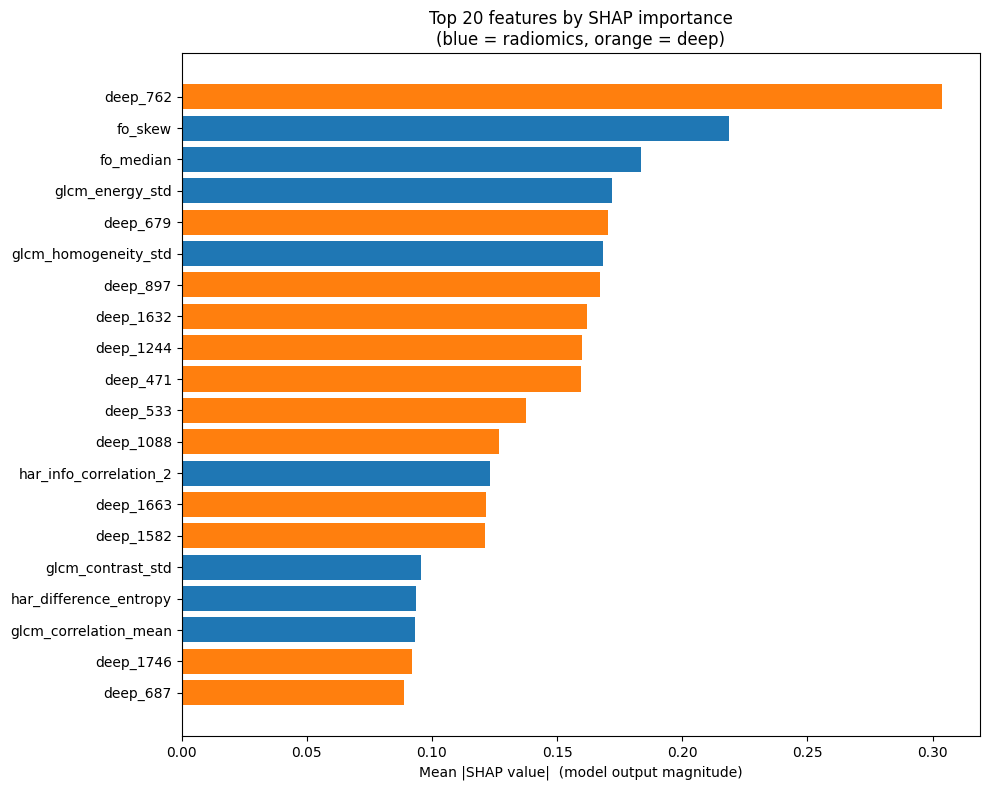


Saved to ..\outputs\shap_global.png


In [5]:
# Create a directory for saving SHAP figures
OUTPUTS.mkdir(exist_ok=True)

# We need to compute mean abs SHAP across classes for the bar plot
# shap_array shape: (n_samples, n_features, n_classes)
# Take absolute value, then average across samples and classes
mean_abs_per_feature = np.abs(shap_array).mean(axis=(0, 2))

# Manual barplot since shap.summary_plot has API quirks across versions
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_indices = np.argsort(mean_abs_per_feature)[-top_n:]
top_features = [selected_names[i] for i in top_indices]
top_values = mean_abs_per_feature[top_indices]
top_colors = ['#1f77b4' if not selected_names[i].startswith('deep_') else '#ff7f0e' 
              for i in top_indices]

ax.barh(range(top_n), top_values, color=top_colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features)
ax.set_xlabel('Mean |SHAP value|  (model output magnitude)')
ax.set_title('Top 20 features by SHAP importance\n(blue = radiomics, orange = deep)')
plt.tight_layout()
plt.savefig(OUTPUTS / 'shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to {OUTPUTS / 'shap_global.png'}")